In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

def make_timedelta(df, col):
    df['seconds'] = df[col]
    df[col] = pd.to_timedelta(df[col], unit='s')

In [2]:
ref_size="100Mb"
ibf_size = 175085704
database_size = 100 * 1024 * 1024
query_size = 1024 * 1024
min_len = 50
window_size = 20

In [3]:
database_size = 96609006
query_size = 10734334

In [4]:
XXSMALL_SIZE = 11
XSMALL_SIZE = 13
SMALL_SIZE = 17
MEDIUM_SIZE = 19
BIGGER_SIZE = 21

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# Benchmark of 100Mb reference vs 1Mb query

In [5]:
def get_runtime_df(filename):
    df = pd.read_csv(filename, sep = "\t")
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)

    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([9, 13, 15], axis = 1, inplace = True)
    more[0] = more[0].astype(str)

    to_remove = []
    for col in more.columns:
        #print(col)
        #print(more[col])
        if (len(np.unique(more[col])) == 1):
            to_remove.append(col)

    to_remove.append(14)
    more.drop(to_remove, axis = 1, inplace = True)

    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df


In [6]:
def get_seg_len_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 8, 9, 10, 13, 14, 15], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df

def get_no_time_df(filename):
    df = pd.read_csv(filename, sep = "\t", header = None)
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([1, 2, 6, 7, 8, 9, 12, 13, 14], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df



In [7]:
1048610 / 3495

300.0314735336195

#### Threads

In [132]:
df = get_seg_len_df(ref_size + "/full.log")
build = df[df["exec-path"] == "build"].copy()

#build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
#io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

In [133]:
np.unique(build["threads"])

array([ 1,  2,  4, 32])

In [134]:
build

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,error-rate,threads
0,49.13,475244,0.5,3,build,100,500,1024,0.06,1
1,3.96,1487004,0.5,3,build,100,500,1024,0.06,32
7,18.43,507356,0.5,3,build,100,500,1024,0.06,2
8,9.72,572580,0.5,3,build,100,500,1024,0.06,4
9,19.07,645848,0.5,3,build,100,100000,1024,0.06,2
...,...,...,...,...,...,...,...,...,...,...
260,165.53,486452,0.5,5,build,500,1000,1000,0.10,4
261,115.26,492424,0.5,5,build,1000,1000,1000,0.10,4
262,74.87,493320,0.5,5,build,2000,1000,1000,0.10,4
263,48.30,492608,0.5,5,build,4000,1000,1000,0.10,4


In [135]:
#data = build[build["max-queued-carts"] == 1000]
#data = data[data["adapt_cutoff"] == 0.5]

data = build[build["threads"] == 1].copy()
data = data[data["seg-count"] == 3495]
data = data[data["cart-max-capacity"] > 1]

In [146]:
# databases * 2 due to forward and reverse
ibf_size = 175085704
database_size = 100 * 1024 * 1024
query_size = 1024 * 1024

data["memory-model"] = (data["Memory (kb)"] * 1000 - (ibf_size + 2 * database_size + 2 * query_size)).astype(int)

seg_len = query_size / data["seg-count"].iloc[0] + min_len
qgram_size = 12
kmers_per_segment = int(seg_len - qgram_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
bytes_per_kmer = 32
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment * bytes_per_kmer).astype(int)

#data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1000), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round(data["memory-model"] / (data["Memory (kb)"] * 1000) * 100, 2)
data

kmers_per_segment	339


,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,error-rate,threads,memory-model,max-kmer-indexes-size,memory-model-error (%)
17,71.32,478236,0.5,3,build,3495,10,1024,0.06,1,91229464,108480,19.08
18,25.19,469852,0.5,3,build,3495,100,1024,0.06,1,81869144,1084800,17.42
19,21.13,470700,0.5,3,build,3495,1000,1024,0.06,1,72953944,10848000,15.50
40,20.29,470468,0.5,3,build,3495,1000,10,0.06,1,72721944,10848000,15.46
41,20.22,468568,0.5,3,build,3495,1000,100,0.06,1,70821944,10848000,15.11
42,20.26,470484,0.5,3,build,3495,1000,1000,0.06,1,72737944,10848000,15.46
64,20.66,470764,0.5,3,build,3495,1000,1,0.06,1,73017944,10848000,15.51
65,20.41,468644,0.5,3,build,3495,1000,2,0.06,1,70897944,10848000,15.13


In [13]:
#data = io[io["max-queued-carts"] == 1000]
#data = data[data["cart-max-capacity"] == 1000]
#data = data[data["seg-count"] == 3495]
#data = data[data["adapt_cutoff"] == 0.5]

data = io[io["threads"] == 1].copy()
data

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,error-rate,threads
2,131.32,287716,0.5,3,build_io,100,500,1024,0.06,1
28,13240.01,770032,0.5,3,build_io,3495,1,1024,0.06,1
29,1481.19,303344,0.5,3,build_io,3495,10,1024,0.06,1
30,247.04,274844,0.5,3,build_io,3495,100,1024,0.06,1
31,131.97,259940,0.5,3,build_io,3495,1000,1024,0.06,1
49,117.84,256768,0.5,3,build_io,3495,1000,10,0.06,1
50,130.80,259268,0.5,3,build_io,3495,1000,100,0.06,1
51,120.40,258508,0.5,3,build_io,3495,1000,1000,0.06,1
58,128.33,258364,0.5,3,build_io,3495,1000,1,0.06,1
59,117.69,261820,0.5,3,build_io,3495,1000,2,0.06,1


#### Cart parameters

In [157]:
ref_size = "10Mb_equal"
df = get_no_time_df(ref_size + "/cart_params_test/full_params.log")
df.head()

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,error-rate,threads
0,24.33,72456,0.5,3,build,3500,10,1000,0.06,1
1,24.34,72224,0.5,3,build,3500,10,1000,0.06,1
2,24.38,73572,0.5,3,build,3500,10,1000,0.06,1
3,20.47,95752,0.5,3,build,3500,100,1000,0.06,1
4,26.33,196956,0.5,3,build,3500,1000,1000,0.06,1


In [158]:
df_all = df.copy()
df = df[df["seg-count"]>100]
df = df[df["error-rate"]==0.06]
#df = df[df["cart-max-capacity"] > 1]
df.tail()

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,error-rate,threads
137,9.40,306800,0.5,3,build_io,3500,1000,1000,0.06,4
138,9.02,396140,0.5,3,build_io,3500,1000,1,0.06,4
139,9.45,287704,0.5,3,build_io,3500,1000,2,0.06,4
140,9.17,360452,0.5,3,build_io,3500,1000,4,0.06,4
141,9.13,295332,0.5,3,build_io,3500,1000,1000,0.06,4


In [159]:
build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

In [160]:
data = build.copy()
data["memory-model"] = (data["Memory (kb)"] * 1000 - (ibf_size + 2 * database_size + query_size)).astype(int)

seg_len = query_size / df["seg-count"].iloc[0] + min_len
kmers_per_segment = int(seg_len - window_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
bytes_per_kmer = 8
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment * bytes_per_kmer).astype(int)
data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1000), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round((data["memory-model"] / (data["Memory (kb)"] * 1000)) * 100, 2)
data.head()

kmers_per_segment	3026


,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads,memory-model,max-kmer-indexes-size,kmer-indexes-frac,memory-model-error (%)
0,24.33,72456,10,1000,1,22770603,242080,0.00,31.43
1,24.34,72224,10,1000,1,22538603,242080,0.00,31.21
2,24.38,73572,10,1000,1,23886603,242080,0.00,32.47
3,20.47,95752,100,1000,1,43887883,2420800,0.03,45.83
4,26.33,196956,1000,1000,1,123304683,24208000,0.12,62.61


                   Time (s)  Memory (kb)  max-queued-carts  threads  \
cart-max-capacity                                                     
10                    6.270      80344.8            1000.0      4.0   
100                   5.242     141500.8            1000.0      4.0   
1000                  7.429     320131.6            1000.0      4.0   

                   kmer-index-size  
cart-max-capacity                   
10                              58  
100                             75  
1000                           241  


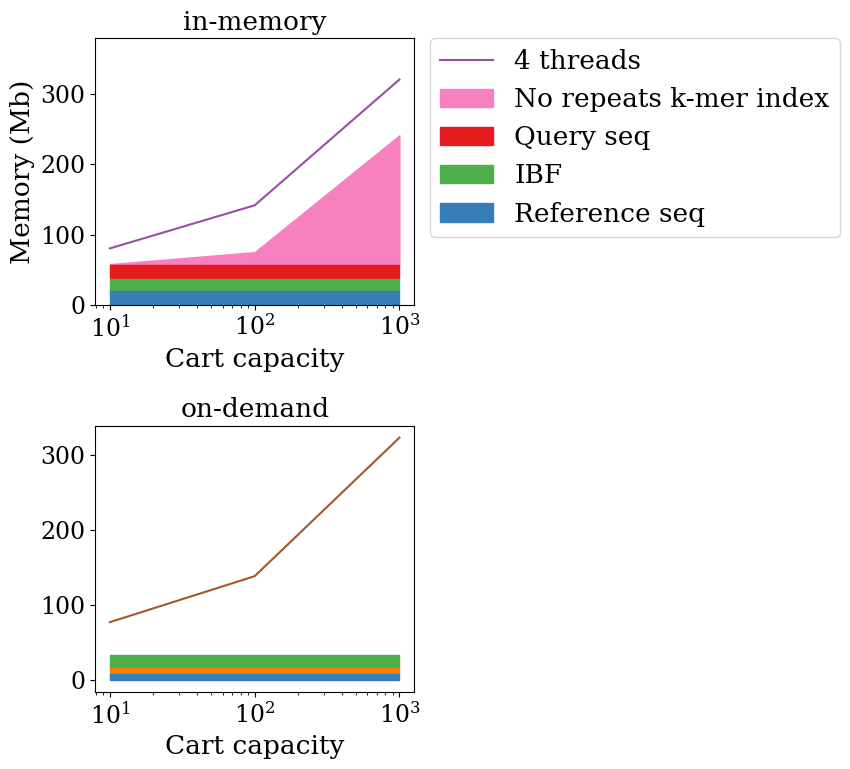

In [185]:
ibf_size = 17944233 + 41414 + 390
database_size = 10 * 1024 * 1024
query_size = 10 * 1024 * 1024

colors = [CB_color_cycle[5], CB_color_cycle[4]]
styles = ["-", "-"]
fig, ax = plt.subplots(2)
fig.set_size_inches(9, 8)

labels = ["1 thread", "4 threads"]

j = 1
i = 0
for t in [4]:    
    data = build.copy()
    data = data[data["threads"] == t]
    data = data[data["cart-max-capacity"] > 1]
    data = data[data["max-queued-carts"] == 1000]
    data = data.sort_values('cart-max-capacity', ascending=True)
    data = data.groupby('cart-max-capacity').agg('mean')
    
    x_len = len(data["Memory (kb)"])
    zeroes = [0] * x_len
    
    databases = [int(np.round(2 * database_size / 1024 / 1024, 0))] * x_len
    ibf = [int(np.round((2 * database_size + ibf_size) / 1024 / 1024, 0))] * x_len
    queries = [int(np.round((2 * database_size + ibf_size + 2 * query_size * 1.002) / 1024 / 1024, 0))] * x_len

    seg_len = query_size / df["seg-count"].iloc[0] + min_len
    bytes_per_kmer = 16
    kmers_per_segment = int(seg_len - window_size + 1)
    prev = int(np.round((2 * database_size + ibf_size + 2 * query_size * 1.002) / 1024 / 1024, 0))
    
    data["kmer-index-size"] = (data["threads"] * data.index.values * kmers_per_segment * bytes_per_kmer / 1024 / 1024 + prev).astype(int)
    print(data)
    
    ax[i].semilogx(data.index.values, data["Memory (kb)"] / 1000, label = labels[j], color = colors[i], linestyle = styles[j])
    ax[i].fill_between(data.index.values, queries, data["kmer-index-size"], label = "No repeats k-mer index", color = CB_color_cycle[3])
    ax[i].fill_between(data.index.values, ibf, queries, label = "Query seq", color = CB_color_cycle[7])
    ax[i].fill_between(data.index.values, databases, ibf, label = "IBF", color = CB_color_cycle[2])
    ax[i].fill_between(data.index.values, zeroes, databases, label = "Reference seq", color = CB_color_cycle[0])
    j += 1

    ax[i].set_title("in-memory")

    i = 1

    ax[i].set_title("on-demand")
    
    data = io.copy()
    data = data[data["threads"] == t]
    data = data[data["cart-max-capacity"] > 1]
    data = data[data["max-queued-carts"] == 1000]
    data = data.sort_values('cart-max-capacity', ascending=True)
    data = data.groupby('cart-max-capacity').agg('mean')
    
    x_len = len(data["Memory (kb)"])
    zeroes = [0] * x_len

    database_segment_size = database_size / 10 * t
    query_segment_size = query_size / 10 * t 
    databases = [int(np.round(2 * database_segment_size / 1024 / 1024, 0))] * x_len
    queries = [int(np.round((2 * database_segment_size + 2 * query_segment_size) / 1024 / 1024, 0))] * x_len
    ibf = [int(np.round((2 * database_segment_size + 2 * query_segment_size + ibf_size) / 1024 / 1024, 0))] * x_len
    ax[i].semilogx(data.index.values, data["Memory (kb)"] / 1000, label = labels[i], color = colors[i])
    ax[i].set_xlabel("Cart capacity")

    ax[i].fill_between(data.index.values, queries, ibf, label = "IBF", color = CB_color_cycle[2])
    ax[i].fill_between(data.index.values, databases, queries, label = "Query sequences", color = CB_color_cycle[1])
    ax[i].fill_between(data.index.values, zeroes, databases, label = "Reference sequences", color = CB_color_cycle[0])
    
for i in range(0, 1, 1):
    ax[i].set_ylim(0, 400)
    ax[i].set_ylim(0, np.max(data["Memory (kb)"]) * 1.2 / 1024)
    ax[i].set_xlabel("Cart capacity")
    ax[i].set_ylabel("Memory (Mb)")
    ax[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_memory_usage.png", dpi=400, bbox_inches='tight')
plt.show()

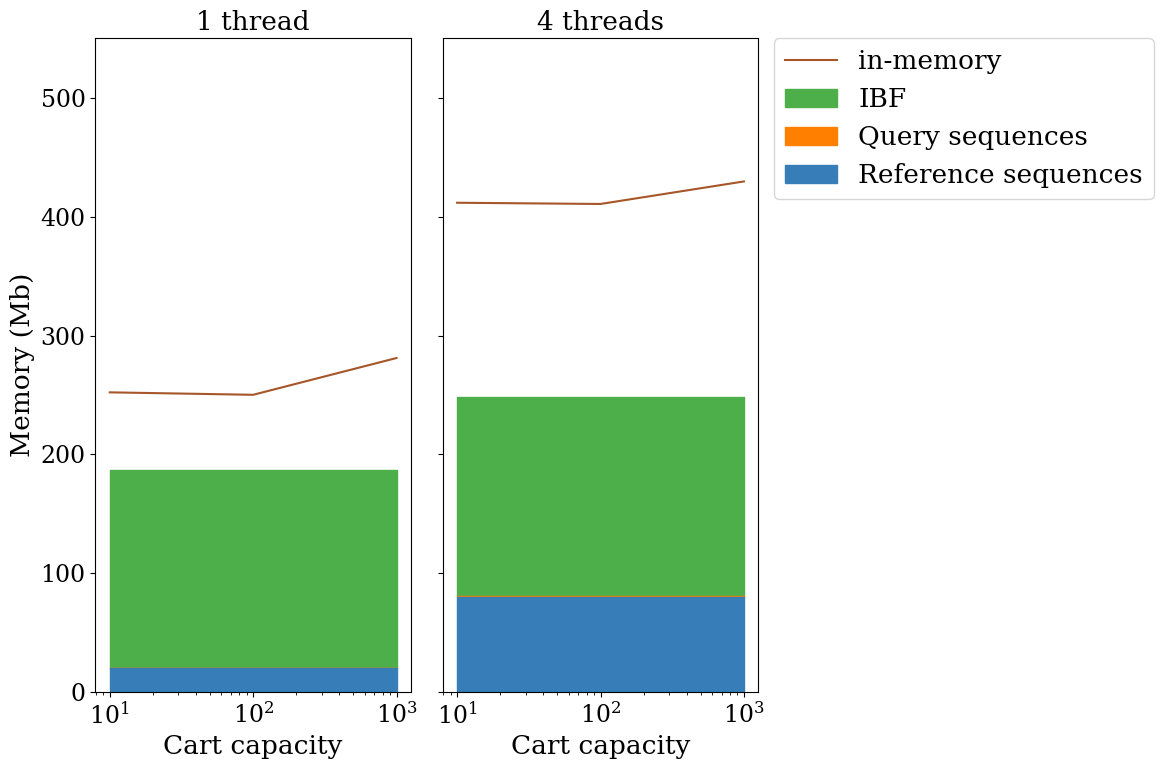

In [80]:
ibf_size = 175085704
database_size = 100 * 1024 * 1024
query_size = 1024 * 1024

colors = [CB_color_cycle[5], CB_color_cycle[4]]
fig, ax = plt.subplots(1, 2, sharey = True)
fig.set_size_inches(12, 8)

labels = ["on-demand", "in-memory"]

j = 0
i = 1
for t in [1, 4]:
    data = io.copy()
    data = data[data["threads"] == t]
    data = data[data["cart-max-capacity"] > 1]
    data = data[data["max-queued-carts"] == 1000]
    data = data.sort_values('cart-max-capacity', ascending=True)
    data = data.groupby('cart-max-capacity').agg('mean')
    ax[j].set_ylim(0, np.max(data["Memory (kb)"]) * 1.2 / 1024)

    x_len = len(data["Memory (kb)"])
    zeroes = [0] * x_len
    database_segment_size = database_size / 10 * t
    query_segment_size = query_size / 10 * t 
    databases = [int(np.round(2 * database_segment_size / 1024 / 1024, 0))] * x_len
    queries = [int(np.round((2 * database_segment_size + 2 * query_segment_size) / 1024 / 1024, 0))] * x_len
    ibf = [int(np.round((2 * database_segment_size + 2 * query_segment_size + ibf_size) / 1024 / 1024, 0))] * x_len
    ax[j].semilogx(data.index.values, data["Memory (kb)"] / 1000, label = labels[i], color = colors[i])
    ax[j].set_xlabel("Cart capacity")

    ax[j].fill_between(data.index.values, queries, ibf, label = "IBF", color = CB_color_cycle[2])
    ax[j].fill_between(data.index.values, databases, queries, label = "Query sequences", color = CB_color_cycle[1])
    ax[j].fill_between(data.index.values, zeroes, databases, label = "Reference sequences", color = CB_color_cycle[0])
    j += 1

ax[0].set_title("1 thread")
ax[1].set_title("4 threads")

ax[0].set_ylabel("Memory (Mb)")
ax[0].set_ylim(0, 550)
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
#fig.savefig(ref_size + "_cart_max_capacity_t.png", dpi=400, bbox_inches='tight')
plt.show()

In [65]:
build

,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads
0,139.63,422596,10,1000,1
1,47.33,435504,100,1000,1
2,37.86,517044,1000,1000,1
3,140.15,425552,10,1000,1
4,47.34,434752,100,1000,1
...,...,...,...,...,...
159,9.80,504668,1000,1000,4
160,9.80,503716,1000,1,4
161,9.80,506348,1000,2,4
162,9.83,501648,1000,4,4


In [20]:
data = io.copy()
#data = data[data["cart-max-capacity"] > 1]
ref_seg_count = 10
data["memory-model"] = (data["Memory (kb)"] * 1024 - (ibf_size + data["threads"] * 2 * database_size / ref_seg_count + query_size)).astype(int)

seg_len = query_size / df["seg-count"].iloc[0] + min_len
kmers_per_segment = int(seg_len - window_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment).astype(int)
data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1024), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round((data["memory-model"] / (data["Memory (kb)"] * 1024)) * 100, 2)
data.head()

kmers_per_segment	3097


,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads,memory-model,max-kmer-indexes-size,kmer-indexes-frac,memory-model-error (%)
20,2607.38,252000,10,1000,1,52875190,30970,0.00,20.49
21,343.87,250244,100,1000,1,50798316,309700,0.00,19.82
22,136.51,265540,1000,1000,1,63674120,3097000,0.01,23.42
23,132.94,265260,1000,1,1,63387400,3097000,0.01,23.34
24,133.43,265348,1000,2,1,63477512,3097000,0.01,23.36


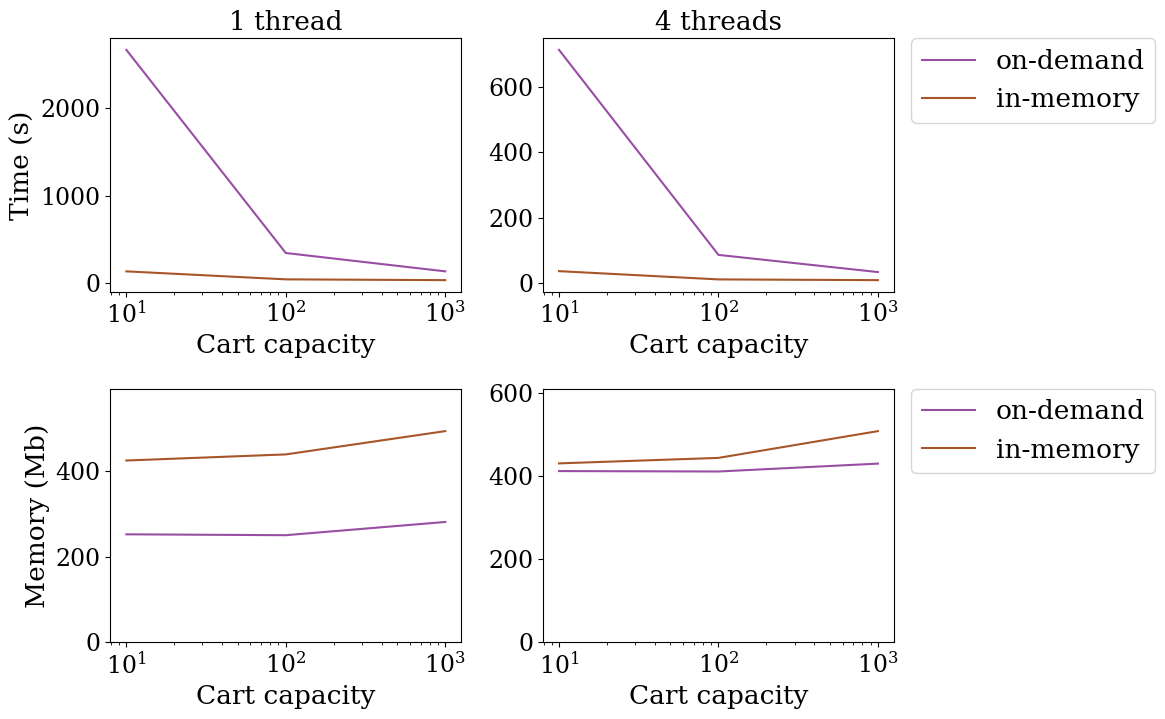

In [50]:
colors = [CB_color_cycle[5], CB_color_cycle[4]]
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(12, 7.5)

labels = ["on-demand", "in-memory"]

j = 0
for t in [1, 4]:
    i = 0
    for data in [io, build]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[0][j].semilogx(data.index.values, data["Time (s)"], color = colors[i], label = labels[i])
        i += 1
        
    i = 0
    for data in [io, build]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1000]
        data = data.sort_values('cart-max-capacity', ascending=True)
        data = data.groupby('cart-max-capacity').agg('mean')
        ax[1][j].set_ylim(0, np.max(data["Memory (kb)"]) * 1.2 / 1000)
        ax[1][j].semilogx(data.index.values, data["Memory (kb)"] / 1000, label = labels[i], color = colors[i])
        ax[0][j].set_xlabel("Cart capacity")
        ax[1][j].set_xlabel("Cart capacity")
        i+=1
    j += 1

ax[0][0].set_title("1 thread")
ax[0][1].set_title("4 threads")

ax[0][0].set_ylabel("Time (s)")
ax[1][0].set_ylabel("Memory (Mb)")

ax[0][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax[1][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
#fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_cart_max_capacity_t.png", dpi=400, bbox_inches='tight')
plt.show()

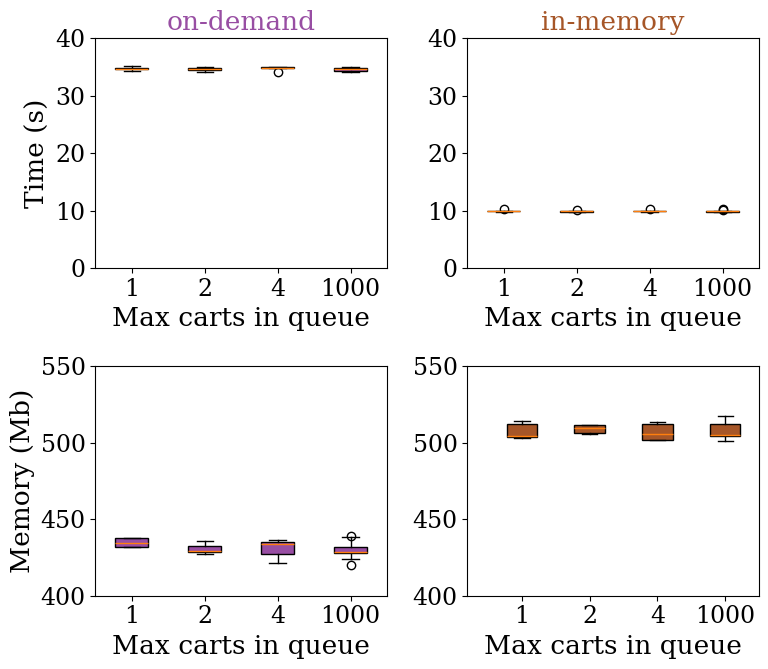

In [51]:
fig, ax = plt.subplots(2, 2, sharey = False)
fig.set_size_inches(8, 7)

def plot_cols(data, ax, column, color, label):
    capacities = [1, 2, 4, 1000]
    data_list = []
    for c in capacities:
        data_list.append(data[data["max-queued-carts"]==c][column])
        
    bplot = ax.boxplot(data_list,
                       patch_artist=True,  # fill with color
                       tick_labels=capacities)  # will be used to label x-ticks

    # fill with colors
    colors = [color] * len(capacities)
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    legend_square = mpatches.Patch(color=color, label=label)
    #ax.legend(handles=[legend_square])
    
col = "max-queued-carts"
colname = "Max carts in queue"
for t in [4]:
    data = df.copy()
    data = data[data["threads"] == t]
    #data = data[data["max-queued-carts"] < 10]
    data = data[data["cart-max-capacity"] == 1000]
    data = data.sort_values(col, ascending=True)

    build = data[data["exec-path"] == "build"].copy()
    build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
    io = data[data["exec-path"] == "build_io"].copy()
    io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

    col = "Time (s)"
    plot_cols(io, ax[0][0], col, CB_color_cycle[5], "in-memory")
    plot_cols(build, ax[0][1], col, CB_color_cycle[4], "on-demand")

    ax[0][0].set_title("on-demand", color = CB_color_cycle[5])
    ax[0][1].set_title("in-memory", color = CB_color_cycle[4])
    ax[0][0].set_xlabel(colname)
    ax[0][1].set_xlabel(colname)
    ax[0][0].set_ylabel("Time (s)")
    ax[0][0].set_ylim(0, 40)
    ax[0][1].set_ylim(0, 40)
    
    #ax[0].plot(data[col], data["Time (s)"], linestyle = "dotted", color = colors[i])

    data = df.copy()
    data = data[data["threads"] == t]
    #data = data[data["max-queued-carts"] < 10]
    data = data[data["cart-max-capacity"] == 1000]
    data = data.sort_values(col, ascending=True)

    build = data[data["exec-path"] == "build"].copy()
    build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
    io = data[data["exec-path"] == "build_io"].copy()
    io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

    col = "Memory (kb)"
    io[col] = io[col] / 1000
    build[col] = build[col] / 1000
    plot_cols(io, ax[1][0], col, CB_color_cycle[5], "in-memory")
    plot_cols(build, ax[1][1], col, CB_color_cycle[4], "on-demand")

    ax[1][0].set_ylabel("Memory (Mb)")
    #ax[1][1].set_ylabel("Memory (Mb)")

    ax[1][0].set_xlabel(colname)
    ax[1][1].set_xlabel(colname)
    ax[1][0].set_ylim(400, 550)
    ax[1][1].set_ylim(400, 550)

    ax[1][1].plot(0.4, 0.4, linestyle = "-.", color = CB_color_cycle[5] , label = "On demand")
    ax[1][1].plot(0.4, 400, color = CB_color_cycle[4], label = "In memory")

    #ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    #fig.suptitle("Searching 10k matches between \n100Mb reference and 1Mb query\n using " + str(t) + " threads")
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    fig.savefig(ref_size + "_max_queued_carts_t" + str(t) + ".png", dpi=400, bbox_inches='tight')
    plt.show()

#### Error rate

In [21]:
ref_size = "100Mb"
bin_cutoff = 0.5
dir_name = "bin_count_test"
bins = [1024, 64, 128, 256, 512, 1024, 2048, 4096] # only for e = 0.06 otherwise always 1024
b = 1024
print("bin-cutoff\terror-rate\tbins\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
for er in [0.02, 0.04, 0.06, 0.08, 0.1]:
    frames = []
    for rep in range(1, 6, 1):
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_seg_len_df(ref_size + "/" + dir_name + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]

        if (er == 0.06):
            acc["bins"] = bins
            df["bins"] = bins
        else:
            acc["bins"] = [1024]
            df["bins"] = [1024]
            
        ref_len = 100 * 1024 * 1024
        df = pd.merge(df, acc, on = ["bins", "adapt_cutoff"], how = "inner")
        df["seg-len"] = (ref_len / df["bins"]).astype(int)
        df = df[df["bins"] == 1024]
        frames.append(df)
    data = pd.concat(frames)
        
    print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(b) + "\t" +
        str(data[data["bins"]==b].iloc[0]["seg-len"]) + "\t" + 
            str(np.round(np.mean(data[data["bins"]==b]["Time (s)"]), 2)) + "\t" +  
                str(int(np.round(np.mean(data[data["bins"]==b]["Memory (kb)"]), 2))) + "\t" +
                        str(np.round(np.mean(data[data["bins"]==b]["missed"]), 2)))

bin-cutoff	error-rate	bins	seg-len	mean time (s)	mean memory (kb)	missed
0.5	0.02	1024	102400	45.37	507425	0.0
0.5	0.04	1024	102400	6.8	506002	0.0
0.5	0.06	1024	102400	9.97	509667	0.01
0.5	0.08	1024	102400	78.66	531382	0.01
0.5	0.1	1024	102400	137.85	520410	0.03


#### Segment length

In [22]:
# bash remove_dist_stellar.sh
ref_size = "100Mb"
bin_cutoff = 0.5

dataframes = []
for er in [0.06, 0.08, 0.1]:
    frames = []
    for rep in range(1, 6, 1):    
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_seg_len_df(ref_size + "/seg_len_test/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/seg_len_test/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        df = df[df["adapt_cutoff"] == bin_cutoff]
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]
        acc["seg-count"] = [10, 20, 50, 250, 500, 1000, 2000, 4000, 8000] * 2
        
        query_len = 1024 * 1024
        df["seg-len"] = (query_len / df["seg-count"]).astype(int)
        df = pd.merge(df, acc, on = ["seg-count", "adapt_cutoff"], how = "inner")
        frames.append(df)
    data = pd.concat(frames)
    dataframes.append(data)
    print("bin-cutoff\terror-rate\tseg-count\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
    for seg_count in [4000, 2000, 1000, 500, 250, 50, 20, 10]:
        print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(seg_count) + "\t" +
            str(data[data["seg-count"]==seg_count].iloc[0]["seg-len"]) + "\t" + 
                str(np.round(np.mean(data[data["seg-count"]==seg_count]["Time (s)"]), 2)) + "\t" +  
                    str(int(np.round(np.mean(data[data["seg-count"]==seg_count]["Memory (kb)"]), 2))) + "\t" +
                            str(np.round(np.mean(data[data["seg-count"]==seg_count]["missed"]), 2)))

bin-cutoff	error-rate	seg-count	seg-len	mean time (s)	mean memory (kb)	missed
0.5	0.06	4000	262	9.84	512009	0.01
0.5	0.06	2000	524	10.84	520674	0.01
0.5	0.06	1000	1048	12.17	521121	0.05
0.5	0.06	500	2097	13.93	562898	0.21
0.5	0.06	250	4194	15.38	563611	0.36
0.5	0.06	50	20971	17.94	636300	0.35
0.5	0.06	20	52428	17.44	634896	0.52
0.5	0.06	10	104857	27.03	699397	0.33
bin-cutoff	error-rate	seg-count	seg-len	mean time (s)	mean memory (kb)	missed
0.5	0.08	4000	262	73.28	555399	0.01
0.5	0.08	2000	524	108.0	579794	0.02
0.5	0.08	1000	1048	155.62	551213	0.07
0.5	0.08	500	2097	194.98	543123	0.22
0.5	0.08	250	4194	211.22	629236	0.35
0.5	0.08	50	20971	211.18	576983	0.58
0.5	0.08	20	52428	230.21	581194	0.51
0.5	0.08	10	104857	216.31	587904	0.57
bin-cutoff	error-rate	seg-count	seg-len	mean time (s)	mean memory (kb)	missed
0.5	0.1	4000	262	127.96	537288	0.03
0.5	0.1	2000	524	190.57	557630	0.03
0.5	0.1	1000	1048	265.16	588608	0.09
0.5	0.1	500	2097	303.6	601200	0.24
0.5	0.1	250	4194	303.09	597305	0.37
0

In [23]:
d = dataframes[0][["seg-count", "seg-len", "Time (s)", "Memory (kb)", "missed"]]
d = d.groupby('seg-count').agg('mean')
d["seg-len"] = d["seg-len"] * 1000000 / 1024 / 1024 + 1
d["seg-len"] = d["seg-len"].astype(int)
d["Memory (Mb)"] = (d["Memory (kb)"] / 1000).astype(int)
d = d.round({"Time (s)" : 1, "missed" : 4})
d.drop(["Memory (kb)"], axis = 1, inplace = True)
d

,seg-len,Time (s),missed,Memory (Mb)
seg-count,,,,
10,100000,27.0,0.3336,699
20,50000,17.4,0.5236,634
50,20000,17.9,0.3536,636
250,4000,15.4,0.3556,563
500,2000,13.9,0.2140,562
1000,1000,12.2,0.0528,521
2000,500,10.8,0.0070,520
4000,250,9.8,0.0060,512
8000,125,9.9,0.0056,511


#### Bin count

In [24]:
# bash remove_dist_stellar.sh
ref_size = "100Mb"
bin_cutoff = 0.5
dir_name = "bin_count_test"
bins = [1024, 64, 128, 256, 512, 1024, 2048, 4096]
for er in [0.06]:
    frames = []
    for rep in range(1, 6, 1):
        er_str = str(er)
        if (er == 0.1):
            er_str = "0.10"
        df = get_seg_len_df(ref_size + "/" + dir_name + "/search_efficiency_rep" + str(rep) + "_e" + er_str + ".log")
        acc = pd.read_csv(ref_size + "/" + dir_name + "/efficiency_rep" + str(rep) + "_e" + er_str + "/valik.stellar.accuracy", sep = "\t", header = None)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]
        acc["bins"] = bins
        df["bins"] = bins
        ref_len = 100 * 1024 * 1024
        df = pd.merge(df, acc, on = ["bins", "adapt_cutoff"], how = "inner")
        df["seg-len"] = (ref_len / df["bins"]).astype(int)
        frames.append(df)
    data = pd.concat(frames)
        
    print("bin-cutoff\terror-rate\tbins\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
    for b in bins[1:]:
        print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(b) + "\t" +
            str(data[data["bins"]==b].iloc[0]["seg-len"]) + "\t" + 
                str(np.round(np.mean(data[data["bins"]==b]["Time (s)"]), 2)) + "\t" +  
                    str(int(np.round(np.mean(data[data["bins"]==b]["Memory (kb)"]), 2))) + "\t" +
                            str(np.round(np.mean(data[data["bins"]==b]["missed"]), 2)))

bin-cutoff	error-rate	bins	seg-len	mean time (s)	mean memory (kb)	missed
0.5	0.06	64	1638400	13.88	557606	0.32
0.5	0.06	128	819200	12.1	527877	0.22
0.5	0.06	256	409600	11.47	529062	0.09
0.5	0.06	512	204800	11.04	504995	0.01
0.5	0.06	1024	102400	9.97	509667	0.01
0.5	0.06	2048	51200	8.89	494041	0.01
0.5	0.06	4096	25600	8.23	505281	0.01


In [25]:
d = data[["bins", "seg-len", "Time (s)", "Memory (kb)", "missed"]]
d = d.groupby('bins').agg('mean')
d["seg-len"] = d["seg-len"] * 1000000 / 1024 / 1024 + 1
d["seg-len"] = d["seg-len"].astype(int)
d["Memory (Mb)"] = (d["Memory (kb)"] / 1024).astype(int)
#make_timedelta(d, "Time (s)")
d = d.round({"Time (s)" : 1, "missed" : 4})
d.drop(["Memory (kb)"], axis = 1, inplace = True)
d

,seg-len,Time (s),missed,Memory (Mb)
bins,,,,
64,1562501,13.9,0.3202,544
128,781251,12.1,0.2172,515
256,390626,11.5,0.0934,516
512,195313,11.0,0.0092,493
1024,97657,10.0,0.0062,497
2048,48829,8.9,0.0060,482
4096,24415,8.2,0.0068,493
